# ESM embedding screening

Исследование качества и структуры ESM-2 эмбеддингов рецепторов.

**Три типа эмбеддингов:**
- `esm2_650m_mean_curated`      — mean-pool по всей последовательности
- `esm2_650m_ecl2_mean_curated` — mean-pool по петле ECL2 (TM4–TM5)
- `esm2_650m_per_residue_curated` → mean по 22 BW-позициям кармана

> **ECL2-данные убраны из `data/embeddings/proteins/`** (`esm2_650m_ecl2_mean_curated.npz`,
> `esm2_650m_ecl2_bw_mean_curated.npz`): исследование показало, что ECL2 не даёт
> преимущества над карманом/фоном (см. `protein-embedding-variants-boost.md`).
> Описание и ячейки ниже остаются как документация; там, где данные нужны для
> расчёта, ячейки аккуратно пропускают недостающее с пояснением, а не падают.
> Исторические результаты (в т.ч. по ECL2) остаются в кэше `results/analysis/*.csv`.

**Предварительные требования:**
```
uv run python scripts/embedding_generation/proteins/05_per_residue_embeddings.py
uv run python scripts/preprocessing/02_bw_numbering.py
```

In [22]:
import sys, warnings, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from orbind import dataset as D

DATA = ROOT / 'data'
FIG  = ROOT / 'notebooks' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
print('repo root:', ROOT)

repo root: <repo>


In [ ]:
# --- загрузка эмбеддингов ---------------------------------------------------
EMB = {}

def _load(name, path, label, note_if_missing=None):
    p = DATA / path
    if p.exists():
        EMB[name] = D.load_npz_dict(p)
        n, d = len(EMB[name]), next(iter(EMB[name].values())).shape[0]
        print(f"{label:<42} {n} рецепторов  dim={d}")
    else:
        extra = f" ({note_if_missing})" if note_if_missing else ""
        print(f"{label:<42} НЕ НАЙДЕН ({p.name}){extra}")

# full — единственный источник истины; curated (409) получаем фильтром по
# pairs_curated.csv, без отдельного persisted-файла.
_curated_recs = set(pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')['receptor'])
_mean_full = D.load_npz_dict(DATA / 'embeddings' / 'proteins' / 'esm2_650m_mean_full.npz')
EMB['mean'] = {k: v for k, v in _mean_full.items() if k in _curated_recs}
print(f"{'mean (вся посл-сть)':<42} {len(EMB['mean'])} рецепторов  "
      f"dim={next(iter(EMB['mean'].values())).shape[0]}")

_ECL_NOTE = 'убран — не даёт преимущества над карманом/фоном, направление закрыто'
_load('ecl2_hydro', 'embeddings/proteins/esm2_650m_ecl2_mean_curated.npz',
     'ECL2 гидрофобность', note_if_missing=_ECL_NOTE)
_load('ecl2_bw',    'embeddings/proteins/esm2_650m_ecl2_bw_mean_curated.npz',
     'ECL2 BW-границы', note_if_missing=_ECL_NOTE)

# pocket22 / mlp_concat / concat22 — все из per-residue npz (full; фильтруем по curated)
_pr_path  = DATA / 'embeddings' / 'proteins' / 'esm2_650m_per_residue_full.npz'
_pos_path = DATA / 'processed' / 'bw_pocket_positions_curated.csv'

if not _pr_path.exists() or not _pos_path.exists():
    missing = [f.name for f in [_pr_path, _pos_path] if not f.exists()]
    print(f"{'pocket22 / mlp_concat / concat22':<42} не готов: {', '.join(missing)}")
else:
    _pr_npz = np.load(str(_pr_path), allow_pickle=False)
    _pos_df = pd.read_csv(_pos_path, index_col='receptor')
    _keys   = list(EMB['mean'].keys())

    # случайный MLP: 1280 -> 256 -> 64, He-init, seed=42
    MLP_OUT = 64
    _rng = np.random.RandomState(42)
    _W1  = (_rng.randn(1280, 256) * np.sqrt(2 / 1280)).astype(np.float32)
    _b1  = np.zeros(256, dtype=np.float32)
    _W2  = (_rng.randn(256, MLP_OUT) * np.sqrt(2 / 256)).astype(np.float32)
    _b2  = np.zeros(MLP_OUT, dtype=np.float32)

    def _mlp(x: np.ndarray) -> np.ndarray:
        """x: [N, 1280] -> [N, MLP_OUT=64]"""
        return np.maximum(0, np.maximum(0, x @ _W1 + _b1) @ _W2 + _b2)

    pool_vecs, mlp_vecs, concat_vecs = [], [], []
    bw_cols = _pos_df.columns.tolist()   # фиксированный порядок 22 BW-колонок

    for k in _keys:
        if k in _pr_npz.files and k in _pos_df.index:
            mat      = _pr_npz[k].astype(np.float32)       # [L, 1280]
            row_pos  = _pos_df.loc[k]
            valid    = row_pos.dropna().astype(int)
            valid    = valid[(valid >= 0) & (valid < len(mat))]

            fallback = mat[valid.values].mean(0) if len(valid) > 0 else mat.mean(0)

            # mean-pool по найденным позициям
            pool_vecs.append(fallback)

            # для каждой из 22 колонок берём позицию или fallback
            pocket_embs = []
            for col in bw_cols:
                raw = row_pos[col]
                idx = int(raw) if pd.notna(raw) and 0 <= int(raw) < len(mat) else -1
                pocket_embs.append(mat[idx] if idx >= 0 else fallback)
            pocket_mat = np.stack(pocket_embs)              # [22, 1280]
            mlp_vecs.append(_mlp(pocket_mat).ravel())       # [22 * 64   = 1408]
            concat_vecs.append(pocket_mat.ravel())          # [22 * 1280 = 28160]
        else:
            fb = EMB['mean'][k]
            pool_vecs.append(fb)
            mlp_vecs.append(_mlp(np.tile(fb, (22, 1))).ravel())
            concat_vecs.append(np.tile(fb, (22, 1)).ravel())

    EMB['pocket22']   = dict(zip(_keys, pool_vecs))
    EMB['mlp_concat'] = dict(zip(_keys, mlp_vecs))
    EMB['concat22']   = dict(zip(_keys, concat_vecs))
    print(f"{'BW-22 mean-pool':<42} {len(pool_vecs)} рецепторов  dim={pool_vecs[0].shape[0]}")
    print(f"{'BW-22 MLP-concat [22x64=1408]':<42} {len(mlp_vecs)} рецепторов  dim={mlp_vecs[0].shape[0]}")
    print(f"{'BW-22 raw-concat [22x1280=28160]':<42} {len(concat_vecs)} рецепторов  dim={concat_vecs[0].shape[0]}")

print(f"\nдоступные варианты: {list(EMB.keys())}")

In [24]:
# --- concat22_pca: PCA-сжатие 1280-d пространства позиций, затем конкат ------
# 1. Все 22*409 эмбеддингов кармана -> облако [8998, 1280].
# 2. PCA по облаку; берём первые N компонент, объясняющих >= 95% дисперсии.
# 3. Рецептор = конкатенация 22 сжатых отрезков длины N  ->  dim = 22*N.
VAR_KEEP = 0.95

if 'concat22' not in EMB:
    print('concat22 не готов (нужен per-residue npz) — пропускаю concat22_pca')
else:
    _pk   = list(EMB['mean'].keys())   # порядок рецепторов (cell-order ещё мог не выполниться)
    P_all = np.stack([EMB['concat22'][k].reshape(22, 1280) for k in _pk])   # [409,22,1280]
    flat  = P_all.reshape(-1, 1280).astype(np.float64)                      # [8998,1280]
    _mu   = flat.mean(0, keepdims=True)
    _U, _S, _Vt = np.linalg.svd(flat - _mu, full_matrices=False)
    _cum = np.cumsum(_S ** 2) / (_S ** 2).sum()
    N_PCA = int(np.searchsorted(_cum, VAR_KEEP) + 1)
    print(f'облако кармана: {flat.shape[0]} векторов x 1280')
    print(f'N компонент для {VAR_KEEP:.0%} дисперсии: {N_PCA}  ->  dim = 22*{N_PCA} = {22 * N_PCA}')

    _comps = _Vt[:N_PCA]                                                     # [N,1280]
    _red = ((P_all.reshape(-1, 1280) - _mu) @ _comps.T) \
            .reshape(len(_pk), 22 * N_PCA).astype(np.float32)
    EMB['concat22_pca'] = dict(zip(_pk, _red))
    print(f"{'BW-22 PCA-concat':<42} {len(_pk)} рецепторов  dim={22 * N_PCA}")
    print(f"\nдоступные варианты: {list(EMB.keys())}")

облако кармана: 8998 векторов x 1280
N компонент для 95% дисперсии: 231  ->  dim = 22*231 = 5082
BW-22 PCA-concat                           409 рецепторов  dim=5082

доступные варианты: ['mean', 'ecl2_hydro', 'ecl2_bw', 'pocket22', 'mlp_concat', 'concat22', 'concat22_pca']


In [25]:
# --- семьи и фиксированный порядок рецепторов ------------------------------
# Порядок вычисляется ОДИН РАЗ по mean-эмбеддингам и используется везде.

bw_ref  = pd.read_csv(DATA / 'processed' / 'bw_ref_used_curated.csv')
seq2ref = bw_ref.set_index('receptor')['ref_entry'].to_dict()

def _family(seq):
    slug = seq2ref.get(seq, 'unk_human').replace('_human', '')
    m    = re.match(r'^(or?\d+)', slug)
    return m.group(1).upper() if m else slug.upper()

keys     = list(EMB['mean'].keys())
E_mean   = np.stack([EMB['mean'][k] for k in keys])
families = [_family(k) for k in keys]
fam_set  = sorted(set(families))

def _cnorm(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)

E_norm = _cnorm(E_mean)
ordered_idx = []
for fam in fam_set:
    idx = [i for i, f in enumerate(families) if f == fam]
    if len(idx) <= 3:
        ordered_idx.extend(idx)
    else:
        Z  = linkage(E_norm[idx], method='average', metric='cosine')
        lo = leaves_list(Z)
        ordered_idx.extend([idx[j] for j in lo])

ORDER = np.array(ordered_idx)   # фиксированный порядок — не менять!

# границы семей для разделительных линий
fam_ord   = [families[i] for i in ORDER]
bounds, fam_labels = [], []
prev = None
for i, f in enumerate(fam_ord):
    if f != prev:
        bounds.append(i)
        fam_labels.append((i, f))
        prev = f

print(f"порядок: {len(ORDER)} рецепторов, {len(fam_set)} семей")
print(pd.Series(families).value_counts().to_string())

порядок: 409 рецепторов, 17 семей
OR2    98
OR5    69
OR4    39
O10    35
O52    32
OR8    31
O51    29
OR7    26
OR1    13
OR6    10
O14     7
OR9     6
O56     5
OR3     4
O11     3
O12     1
O13     1


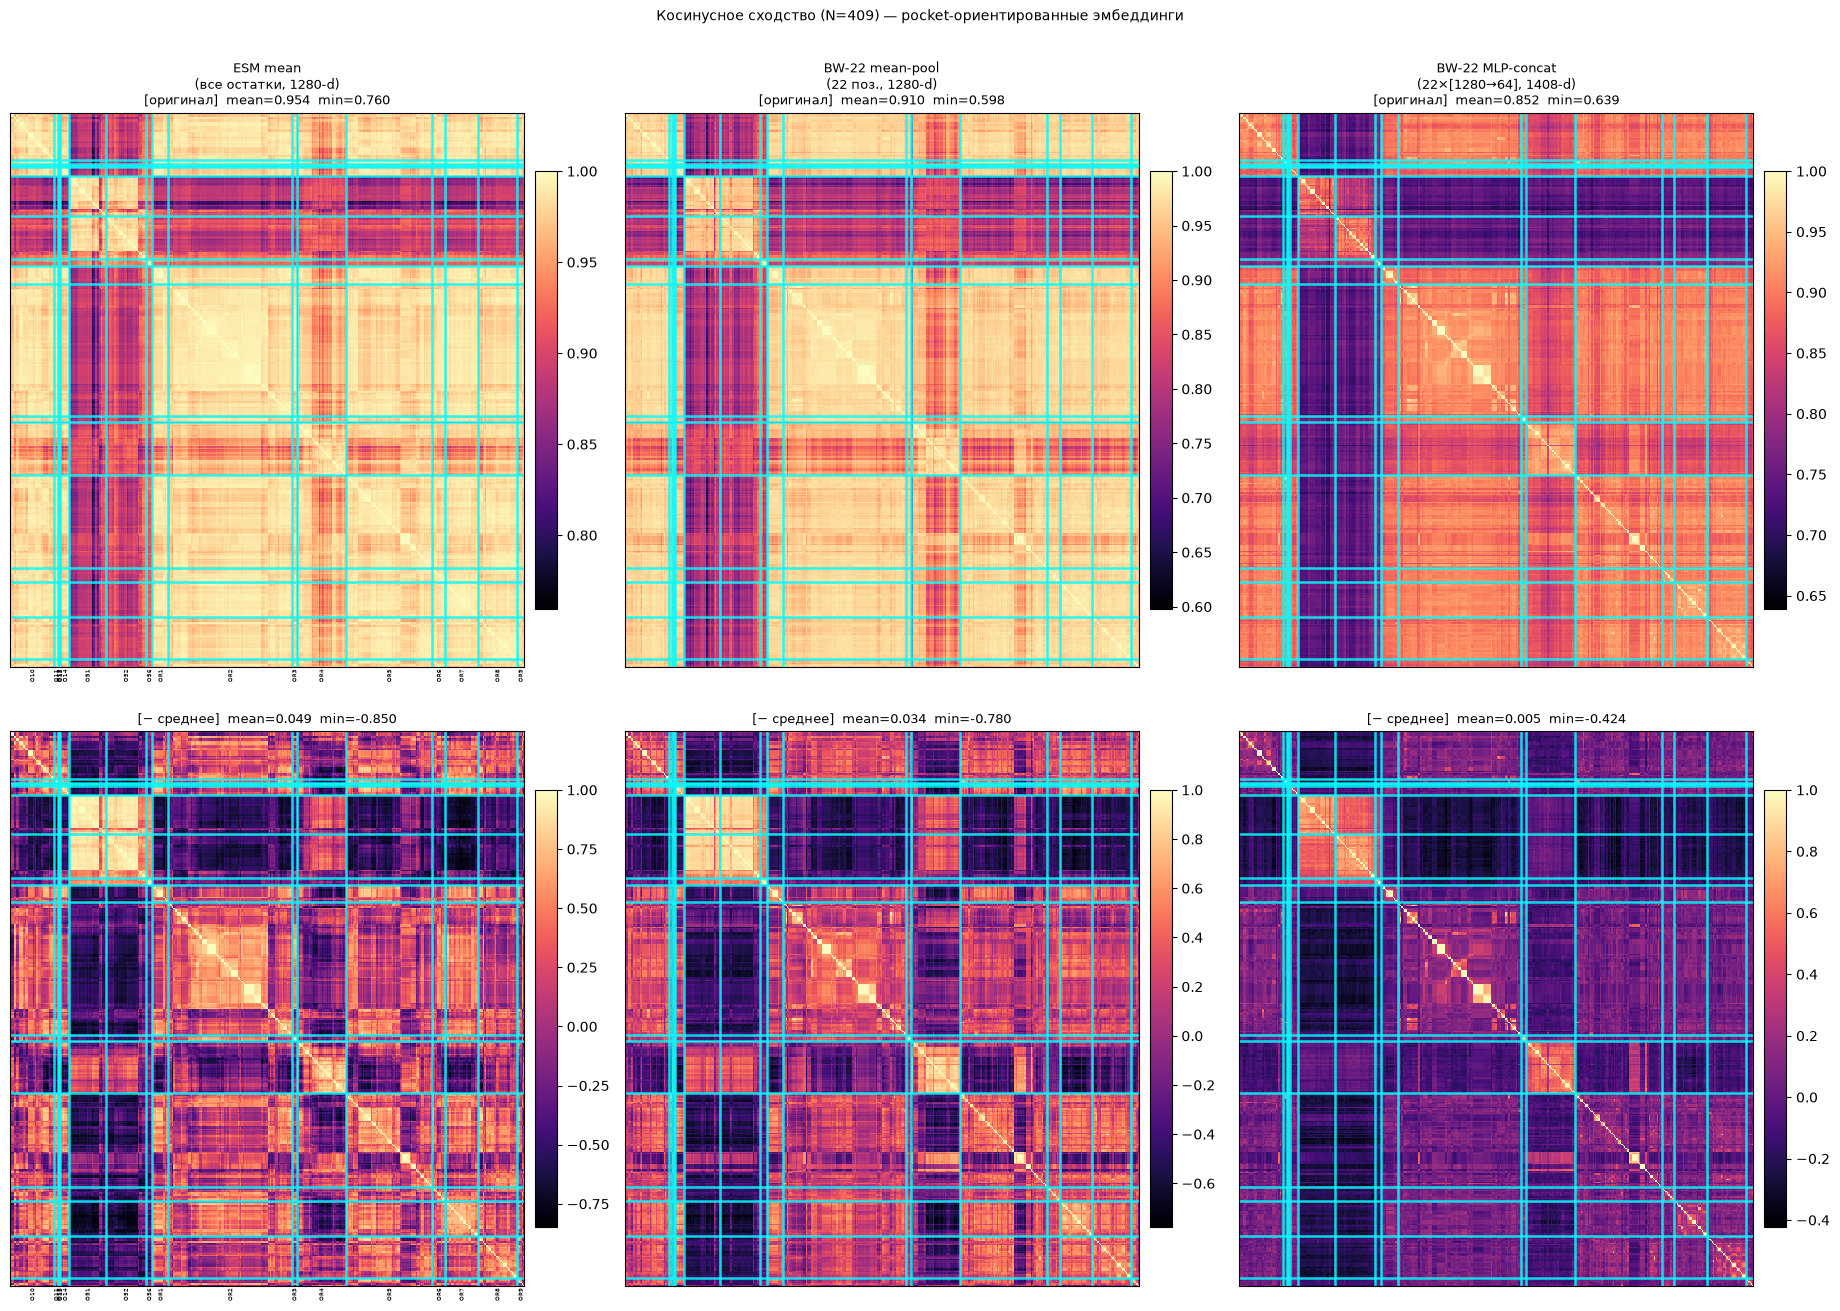

saved -> cosine_top3.png


In [26]:
# --- Рисунок 1: три матрицы × два варианта (raw / mean-centered) -----------
# Верхний ряд:  оригинальные эмбеддинги
# Нижний ряд:   те же эмбеддинги минус их среднее по всем рецепторам

TOP = [
    ('mean',       'ESM mean\n(все остатки, 1280-d)'),
    ('pocket22',   'BW-22 mean-pool\n(22 поз., 1280-d)'),
    ('mlp_concat', 'BW-22 MLP-concat\n(22×[1280→64], 1408-d)'),
]

def _cossim(emb_dict, order):
    E  = np.stack([emb_dict[k] for k in keys])
    En = _cnorm(E)[order]
    return En @ En.T

def _center(emb_dict):
    E  = np.stack(list(emb_dict.values()))
    mu = E.mean(0)
    return {k: v - mu for k, v in emb_dict.items()}

N      = len(ORDER)
SEP_LW = 1.8
mids   = [(bounds[j] + (bounds[j+1] if j+1 < len(bounds) else N)) / 2
          for j in range(len(bounds))]

avail_top = [(n, t) for n, t in TOP if n in EMB]
nc = len(avail_top)

fig, axes = plt.subplots(2, nc, figsize=(6 * nc + 0.5, 13))

row_labels = ['оригинал', '− среднее']
for r, centered in enumerate([False, True]):
    for c, (name, title) in enumerate(avail_top):
        ax  = axes[r, c]
        src = _center(EMB[name]) if centered else EMB[name]
        S   = _cossim(src, ORDER)
        off = S[~np.eye(N, dtype=bool)]
        im  = ax.imshow(S, cmap='magma', vmin=off.min(), vmax=1.0,
                        interpolation='nearest', aspect='auto')
        header = title if r == 0 else ''
        ax.set_title(f"{header}\n[{row_labels[r]}]  mean={off.mean():.3f}  min={off.min():.3f}",
                     fontsize=9)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        for b in bounds[1:]:
            ax.axhline(b - 0.5, color='cyan', lw=SEP_LW, alpha=0.85)
            ax.axvline(b - 0.5, color='cyan', lw=SEP_LW, alpha=0.85)
    # метки семей слева
    for mid, (_, name_f) in zip(mids, fam_labels):
        axes[r, 0].text(mid, N + 1, name_f, ha='center', va='top',
                        fontsize=4.5, rotation=90, color='black')

fig.suptitle(f"Косинусное сходство (N={N}) — pocket-ориентированные эмбеддинги",
             fontsize=10, y=1.005)
fig.tight_layout()
fname = FIG / 'cosine_top3.png'
fig.savefig(fname, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved -> {fname.name}')

In [ ]:
# --- Рисунок 2: две матрицы × два варианта (raw / mean-centered) -----------
# Верхний ряд:  оригинальные эмбеддинги
# Нижний ряд:   те же эмбеддинги минус их среднее по всем рецепторам
#
# ECL2-данные убраны (направление закрыто, см. заметку в шапке ноутбука) —
# если файлов нет, ячейка просто пропускает график вместо падения.

BOT = [
    ('ecl2_hydro', 'ECL2 гидрофобность\n(TM детектор, 1280-d)'),
    ('ecl2_bw',    'ECL2 BW-границы\n(точные TM4/TM5, 1280-d)'),
]

avail_bot = [(n, t) for n, t in BOT if n in EMB]
nc2 = len(avail_bot)

if nc2 == 0:
    print('ECL2-эмбеддинги отсутствуют (данные убраны, направление закрыто) — график пропущен')
else:
    fig, axes = plt.subplots(2, nc2, figsize=(6 * nc2 + 0.5, 13))
    if nc2 == 1:
        axes = axes.reshape(2, 1)

    for r, centered in enumerate([False, True]):
        for c, (name, title) in enumerate(avail_bot):
            ax  = axes[r, c]
            src = _center(EMB[name]) if centered else EMB[name]
            S   = _cossim(src, ORDER)
            off = S[~np.eye(N, dtype=bool)]
            im  = ax.imshow(S, cmap='magma', vmin=off.min(), vmax=1.0,
                            interpolation='nearest', aspect='auto')
            header = title if r == 0 else ''
            ax.set_title(f"{header}\n[{row_labels[r]}]  mean={off.mean():.3f}  min={off.min():.3f}",
                         fontsize=9)
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
            for b in bounds[1:]:
                ax.axhline(b - 0.5, color='cyan', lw=SEP_LW, alpha=0.85)
                ax.axvline(b - 0.5, color='cyan', lw=SEP_LW, alpha=0.85)
        for mid, (_, name_f) in zip(mids, fam_labels):
            axes[r, 0].text(mid, N + 1, name_f, ha='center', va='top',
                            fontsize=4.5, rotation=90, color='black')

    fig.suptitle(f"Косинусное сходство (N={N}) — ECL2-эмбеддинги: метод разметки",
                 fontsize=10, y=1.005)
    fig.tight_layout()
    fname = FIG / 'cosine_bot2.png'
    fig.savefig(fname, dpi=140, bbox_inches='tight')
    plt.show()
    print(f'saved -> {fname.name}')

In [ ]:
# --- 3D t-SNE per-residue эмбеддингов одного рецептора --------------------
# Каждая точка = один остаток, цвет = позиция в последовательности (1…L).
# Обведённые точки — 22 BW-позиции кармана.
#
# RECEPTOR_SEQ = None  → авто-выбор: рецептор с наибольшим % identity к эталону
RECEPTOR_SEQ = None   # или вставь строку последовательности вручную

_pr_path  = DATA / 'embeddings' / 'proteins' / 'esm2_650m_per_residue_full.npz'
_pos_path = DATA / 'processed' / 'bw_pocket_positions_curated.csv'

if not _pr_path.exists():
    print(f'per-residue embeddings not ready: {_pr_path.name}')
    print('запустить: uv run python scripts/embedding_generation/proteins/05_per_residue_embeddings.py')
else:
    import sklearn
    from sklearn.manifold import TSNE
    from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

    pr_npz = np.load(str(_pr_path), allow_pickle=False)
    pos_df = pd.read_csv(_pos_path, index_col='receptor')

    # ── выбор рецептора ───────────────────────────────────────────────────────
    if RECEPTOR_SEQ is None:
        cand = bw_ref[bw_ref['pct_identity'] < 99.9].sort_values(
            'pct_identity', ascending=False)
        for _, row in cand.iterrows():
            if row['receptor'] in pr_npz.files:
                RECEPTOR_SEQ = row['receptor']
                _ref   = row['ref_entry']
                _pctid = row['pct_identity']
                break

    if RECEPTOR_SEQ is None or RECEPTOR_SEQ not in pr_npz.files:
        print('подходящий рецептор не найден в per-residue npz')
    else:
        mat = pr_npz[RECEPTOR_SEQ].astype(np.float32)   # [L, 1280]
        L   = mat.shape[0]
        print(f'рецептор: {RECEPTOR_SEQ[:40]}…  L={L}  ref={_ref}  id={_pctid:.1f}%')

        pocket_pos = set()
        if RECEPTOR_SEQ in pos_df.index:
            vals = pos_df.loc[RECEPTOR_SEQ].dropna().astype(int).values
            pocket_pos = set(int(v) for v in vals if 0 <= v < L)
        print(f'pocket positions annotated: {len(pocket_pos)}/22')

        # ── t-SNE → 3 компоненты ─────────────────────────────────────────────
        # n_iter переименован в max_iter в sklearn >= 1.4
        _tsne_iter_kwarg = (
            'max_iter' if tuple(int(x) for x in sklearn.__version__.split('.')[:2]) >= (1, 4)
            else 'n_iter'
        )
        print('running t-SNE (3D)…')
        tsne = TSNE(n_components=3, perplexity=min(30, L // 3),
                    random_state=42, verbose=0,
                    **{_tsne_iter_kwarg: 1000})
        proj = tsne.fit_transform(mat)   # [L, 3]
        print(f't-SNE done  KL={tsne.kl_divergence_:.3f}')

        colors = np.arange(L)

        # ── график ────────────────────────────────────────────────────────────
        fig = plt.figure(figsize=(11, 8))
        ax  = fig.add_subplot(111, projection='3d')

        sc = ax.scatter(
            proj[:, 0], proj[:, 1], proj[:, 2],
            c=colors, cmap='rainbow', s=18, alpha=0.7,
            linewidths=0, depthshade=True,
        )

        if pocket_pos:
            pidx = sorted(pocket_pos)
            ax.scatter(
                proj[pidx, 0], proj[pidx, 1], proj[pidx, 2],
                c=np.array(pidx), cmap='rainbow', vmin=0, vmax=L - 1,
                s=140, alpha=1.0, edgecolors='white', linewidths=1.5,
                zorder=5, label=f'BW-22 ({len(pidx)} поз.)',
            )

        cb = fig.colorbar(sc, ax=ax, pad=0.1, fraction=0.03)
        cb.set_label('позиция в последовательности', fontsize=8)

        ax.set_xlabel('t-SNE 1', fontsize=8)
        ax.set_ylabel('t-SNE 2', fontsize=8)
        ax.set_zlabel('t-SNE 3', fontsize=8)
        ax.set_title(
            f'Per-residue ESM-2 → t-SNE 3D  │  L={L} остатков\n'
            f'ref={_ref}  id={_pctid:.1f}%  │  '
            f'perplexity={tsne.perplexity}  KL={tsne.kl_divergence_:.3f}',
            fontsize=9,
        )
        ax.legend(fontsize=8, loc='upper left')
        ax.tick_params(labelsize=7)

        fig.tight_layout()
        fname = FIG / 'per_residue_tsne3d.png'
        fig.savefig(fname, dpi=140, bbox_inches='tight')
        plt.show()
        print(f'saved -> {fname.name}')

In [ ]:
# --- Косинусное сходство: «фоновые» остатки (всё кроме BW-22 и ECL2) -------
# Для каждого рецептора берём mean-pool по всем позициям, которые НЕ входят
# ни в 22 BW-позиции кармана, ни в петлю ECL2 (по BW-границам TM4/TM5).

_pr_path  = DATA / 'embeddings' / 'proteins' / 'esm2_650m_per_residue_full.npz'
_pos_path = DATA / 'processed' / 'bw_pocket_positions_curated.csv'
_bw_path  = DATA / 'processed' / 'bw_numbering_curated.csv'

if not _pr_path.exists():
    print(f'per-residue npz не готов: {_pr_path.name}')
else:
    _pr_npz  = np.load(str(_pr_path), allow_pickle=False)
    _pos_df  = pd.read_csv(_pos_path, index_col='receptor')

    # ECL2 границы (0-based) из BW-разметки
    _bw_long = pd.read_csv(_bw_path).dropna(subset=['seq_pos'])
    _bw_long['helix']   = _bw_long['bw_number'].str.split('.').str[0]
    _bw_long['seq_pos'] = _bw_long['seq_pos'].astype(int)
    _tm4_end   = _bw_long[_bw_long['helix'] == '4'].groupby('receptor')['seq_pos'].max()
    _tm5_start = _bw_long[_bw_long['helix'] == '5'].groupby('receptor')['seq_pos'].min()

    bg_vecs, n_incl_list = [], []
    for k in keys:
        if k not in _pr_npz.files:
            bg_vecs.append(EMB['mean'][k])
            n_incl_list.append(-1)
            continue

        mat = _pr_npz[k].astype(np.float32)   # [L, 1280]
        L   = len(mat)
        excluded = set()

        # исключаем 22 BW pocket позиции
        if k in _pos_df.index:
            idxs = _pos_df.loc[k].dropna().astype(int).values
            excluded.update(int(i) for i in idxs if 0 <= i < L)

        # исключаем ECL2 (0-based inclusive)
        if k in _tm4_end.index and k in _tm5_start.index:
            ecl2_s = int(_tm4_end[k]) + 1
            ecl2_e = int(_tm5_start[k]) - 1
            if ecl2_e >= ecl2_s:
                excluded.update(range(ecl2_s, ecl2_e + 1))

        included = [i for i in range(L) if i not in excluded]
        bg_vecs.append(mat[included].mean(0) if included else mat.mean(0))
        n_incl_list.append(len(included))

    valid = [n for n in n_incl_list if n >= 0]
    print(f"рецепторов: {len(bg_vecs)}")
    print(f"включено остатков (не BW-22, не ECL2): "
          f"min={min(valid)}  mean={sum(valid)/len(valid):.0f}  max={max(valid)}")
    print(f"исключено в среднем: ~{310 - sum(valid)//len(valid)} из ~310")

    # plot: raw + centered
    EMB_BG = dict(zip(keys, bg_vecs))

    fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
    for ax, (centered, label) in zip(axes, [(False, 'оригинал'), (True, '− среднее')]):
        src = _center(EMB_BG) if centered else EMB_BG
        S   = _cossim(src, ORDER)
        off = S[~np.eye(N, dtype=bool)]
        im  = ax.imshow(S, cmap='magma', vmin=off.min(), vmax=1.0,
                        interpolation='nearest', aspect='auto')
        ax.set_title(
            f"Фоновые остатки (вне BW-22 и ECL2)\n"
            f"[{label}]  mean={off.mean():.3f}  min={off.min():.3f}",
            fontsize=9,
        )
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        for b in bounds[1:]:
            ax.axhline(b - 0.5, color='cyan', lw=SEP_LW, alpha=0.85)
            ax.axvline(b - 0.5, color='cyan', lw=SEP_LW, alpha=0.85)
        for mid, (_, name_f) in zip(mids, fam_labels):
            ax.text(mid, N + 1, name_f, ha='center', va='top',
                    fontsize=4.5, rotation=90, color='black')

    fig.suptitle(
        f"Косинусное сходство (N={N}) — mean-pool по остаткам вне кармана и ECL2",
        fontsize=10, y=1.005,
    )
    fig.tight_layout()
    fname = FIG / 'cosine_background.png'
    fig.savefig(fname, dpi=140, bbox_inches='tight')
    plt.show()
    print(f'saved -> {fname.name}')

BW-позиций: 275  карман: 22  не-карман: 253
идентичность по всем BW…
идентичность по не-карманным BW…


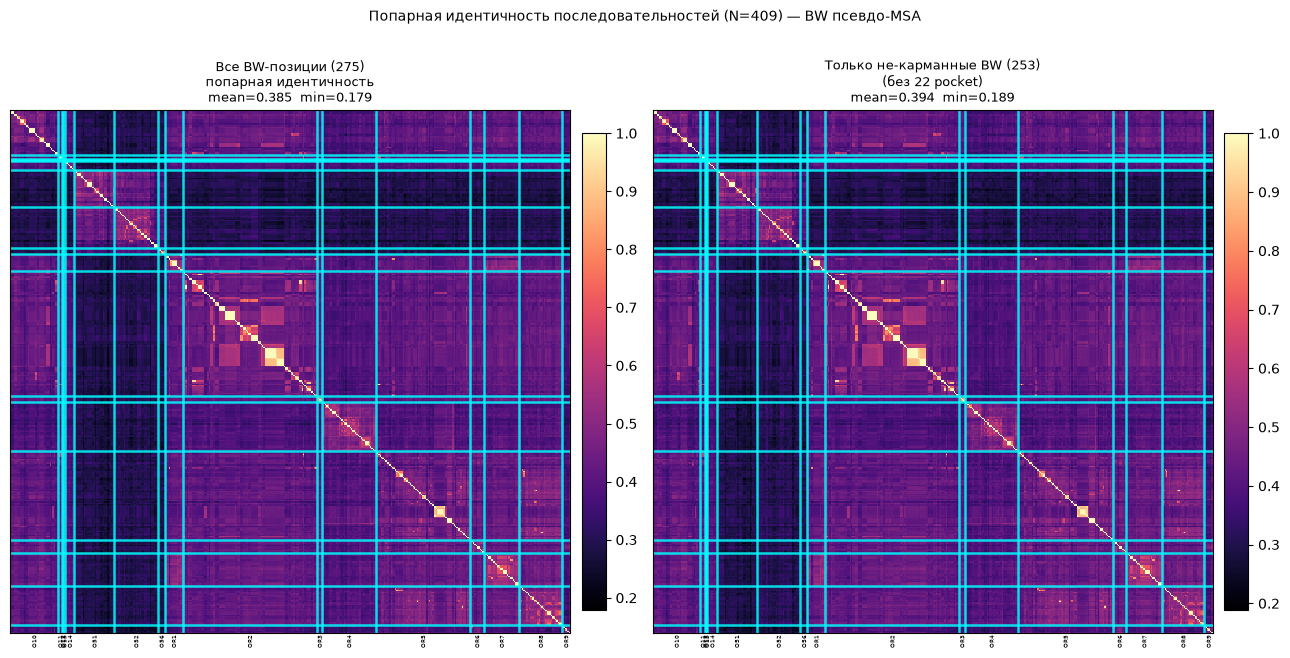

saved -> seqid_bw.png


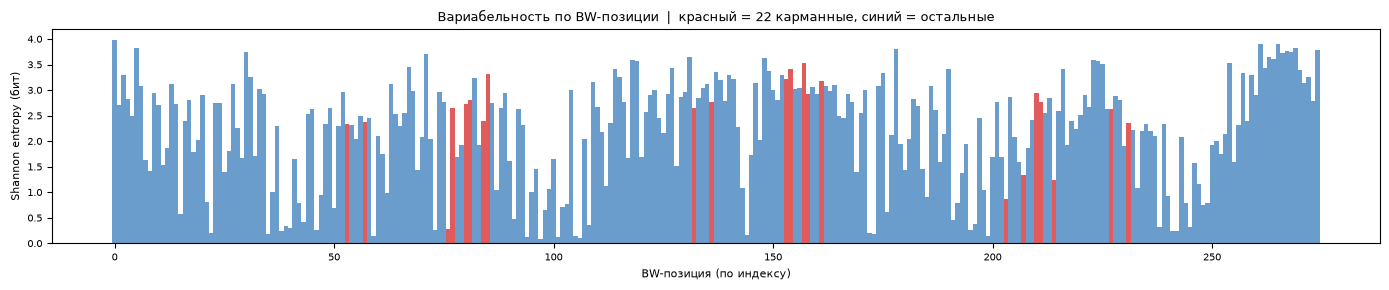

saved -> bw_position_entropy.png


In [30]:
# --- Попарная идентичность последовательностей через BW-выравнивание --------
POCKET_PFXS = {
    '2.53','2.57','3.28','3.29','3.32','3.33','3.36','3.37',
    '4.57','4.61','5.38','5.39','5.42','5.43','5.46',
    '6.44','6.48','6.51','6.52','6.55','7.35','7.39',
}

_bw_long = pd.read_csv(DATA / 'processed' / 'bw_numbering_curated.csv')
_bw_wide = _bw_long.pivot_table(
    index='receptor', columns='bw_number', values='amino_acid', aggfunc='first'
).reindex(keys)

# columns — это pandas Index; .str.split().str[0] возвращает тоже Index,
# .isin() на Index уже отдаёт numpy array — .values не нужен
_col_pfx  = _bw_wide.columns.str.split('x').str[0]
_is_pkt   = _col_pfx.isin(POCKET_PFXS)          # numpy bool array
print(f"BW-позиций: {len(_bw_wide.columns)}  карман: {_is_pkt.sum()}  "
      f"не-карман: {(~_is_pkt).sum()}")

_AA_ENC = {a: i+1 for i, a in enumerate('ACDEFGHIKLMNPQRSTVWY')}
_vals   = _bw_wide.values
_mat    = np.array(
    [[_AA_ENC.get(x, 0) if isinstance(x, str) else 0 for x in row]
     for row in _vals], dtype=np.int8
)

_mat_scaffold = _mat[:, ~_is_pkt]

def _pairwise_id(mat_int):
    N = len(mat_int)
    valid = mat_int > 0
    S = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        both  = valid[i] & valid
        match = both & (mat_int[i] == mat_int)
        denom = both.sum(1).astype(np.float32)
        S[i]  = np.where(denom > 0, match.sum(1) / denom, 0.0)
    return S

print('идентичность по всем BW…')
S_all  = _pairwise_id(_mat)[np.ix_(ORDER, ORDER)]
print('идентичность по не-карманным BW…')
S_scaf = _pairwise_id(_mat_scaffold)[np.ix_(ORDER, ORDER)]

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, (S, label) in zip(axes, [
    (S_all,  f'Все BW-позиции ({len(_bw_wide.columns)})\nпопарная идентичность'),
    (S_scaf, f'Только не-карманные BW ({(~_is_pkt).sum()})\n(без 22 pocket)'),
]):
    off = S[~np.eye(N, dtype=bool)]
    im  = ax.imshow(S, cmap='magma', vmin=off.min(), vmax=1.0,
                    interpolation='nearest', aspect='auto')
    ax.set_title(f"{label}\nmean={off.mean():.3f}  min={off.min():.3f}", fontsize=9)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    for b in bounds[1:]:
        ax.axhline(b - 0.5, color='cyan', lw=SEP_LW, alpha=0.85)
        ax.axvline(b - 0.5, color='cyan', lw=SEP_LW, alpha=0.85)
    for mid, (_, name_f) in zip(mids, fam_labels):
        ax.text(mid, N + 1, name_f, ha='center', va='top',
                fontsize=4.5, rotation=90, color='black')

fig.suptitle(f"Попарная идентичность последовательностей (N={N}) — BW псевдо-MSA",
             fontsize=10, y=1.005)
fig.tight_layout()
fname = FIG / 'seqid_bw.png'
fig.savefig(fname, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved -> {fname.name}')

# --- вариабельность по позиции: Shannon entropy ------------------------------
_col_entropy = []
for p in range(_mat.shape[1]):
    col = _mat[:, p]; col = col[col > 0]
    if len(col) == 0:
        _col_entropy.append(0.0); continue
    _, cnt = np.unique(col, return_counts=True)
    pk = cnt / cnt.sum()
    _col_entropy.append(float(-(pk * np.log2(pk + 1e-12)).sum()))

_ent = np.array(_col_entropy)
fig2, ax2 = plt.subplots(figsize=(14, 3))
colors_bar = np.where(_is_pkt, '#e05c5c', '#6a9ccc')
ax2.bar(np.arange(len(_ent)), _ent, color=colors_bar, width=1.0, linewidth=0)
ax2.set_xlabel('BW-позиция (по индексу)', fontsize=8)
ax2.set_ylabel('Shannon entropy (бит)', fontsize=8)
ax2.set_title('Вариабельность по BW-позиции  |  красный = 22 карманные, синий = остальные',
              fontsize=9)
ax2.tick_params(labelsize=7)
fig2.tight_layout()
fname2 = FIG / 'bw_position_entropy.png'
fig2.savefig(fname2, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved -> {fname2.name}')


---
## Бейзлайн (XGBoost) на всех вариантах белковых эмбеддингов

Признак = `[молекула GIN ‖ белок]`, голова — XGBoost, три сплита.
Переиспользуем уже посчитанные `EMB` (cell-load) и `EMB_BG` (фоновая ячейка);
one-hot контроли строятся прямо в ячейке.

| вариант | что внутри |
|---|---|
| `random` | гауссов шум на каждую строку — пол (контроль) |
| `onehot` | one-hot идентичности рецептора (409-d) — «справочник» |
| `onehot_fam` | one-hot рецептора + one-hot семьи (409+17 = 426-d) |
| `mean` | mean-pool ESM по всей последовательности |
| `pocket22` | mean-pool по 22 BW-позициям |
| `mlp22` | случайный MLP 1280→64 по 22 позициям, конкат (1408-d) |
| `concat22_pca` | PCA-сжатый конкат кармана (22×N, N@95%) — заменитель сырого concat22 (28160-d, OOM в бустинге) |
| `ecl2_hydro`* | ECL2 по гидрофобности |
| `ecl2_bw`* | ECL2 по BW-границам TM4/TM5 |
| `background` | mean-pool по остаткам вне BW-22 и ECL2 |

\* ECL2-данные убраны из `data/embeddings/proteins/` (направление закрыто — не
дают преимущества над карманом/фоном). Ячейка ниже пропускает эти два варианта
при живом прогоне, но их исторические числа остаются в кэше/таблице ниже из
`results/analysis/protein_variants_boost.csv`.

In [ ]:
# --- XGBoost across protein variants (с дисковым кэшем) ---------------------
import json
from orbind import dataset as D
from orbind.baselines import run_one

PAIRS = pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')
GIN   = D.load_npz_dict(DATA / 'embeddings' / 'molecules' / 'gin_supervised_contextpred.npz')
print(f'pairs={len(PAIRS)}  molecules={len(GIN)}')

# --- one-hot контроли: идентичность рецептора и идентичность + семья --------
_oh_keys = list(EMB['mean'].keys())                 # 409 рецепторов
_eye_r   = np.eye(len(_oh_keys), dtype=np.float32)
ONEHOT   = {r: _eye_r[i] for i, r in enumerate(_oh_keys)}            # 409-d

_bwref = pd.read_csv(DATA / 'processed' / 'bw_ref_used_curated.csv') \
            .set_index('receptor')['ref_entry'].to_dict()
def _fam(r):
    s = _bwref.get(r, 'unk_human').replace('_human', '')
    m = re.match(r'^(or?\d+)', s)
    return m.group(1).upper() if m else s.upper()
_fams  = sorted({_fam(r) for r in _oh_keys})
_fi    = {f: i for i, f in enumerate(_fams)}
_eye_f = np.eye(len(_fams), dtype=np.float32)
ONEHOT_FAM = {r: np.concatenate([_eye_r[i], _eye_f[_fi[_fam(r)]]])   # 409+17 = 426-d
              for i, r in enumerate(_oh_keys)}

# источник эмбеддингов: уже посчитанные dict-ы из верхних ячеек
PROT_VARIANTS = {
    'random':     (EMB['mean'],     True),    # шумовой пол (контроль)
    'onehot':     (ONEHOT,          False),   # идентичность рецептора (409-d)
    'onehot_fam': (ONEHOT_FAM,      False),   # идентичность + семья (426-d)
    'mean':       (EMB['mean'],     False),
    'pocket22':   (EMB['pocket22'], False),
    'mlp22':      (EMB['mlp_concat'], False),
}
# Сырой concat22 (28160-d) в бустинг НЕ берём — XGBoost OOM-ит (~6 ГБ гистограмм).
# Его компактный эквивалент — concat22_pca (22*N). Сам concat22 остаётся для
# cosine/PCA-ячеек, где памяти хватает.
if 'concat22_pca' in EMB:
    PROT_VARIANTS['concat22_pca'] = (EMB['concat22_pca'], False)
# ecl2_hydro/ecl2_bw: данные убраны (направление закрыто) — добавляем в живой
# прогон только если EMB их всё-таки содержит; иначе просто нет этих строк
# (исторические значения уже подтянуты из protein_variants_boost.csv ниже).
for _n in ['ecl2_hydro', 'ecl2_bw']:
    if _n in EMB:
        PROT_VARIANTS[_n] = (EMB[_n], False)
if 'EMB_BG' in dir():
    PROT_VARIANTS['background'] = (EMB_BG, False)
else:
    print('! EMB_BG не найден — запусти фоновую ячейку (14aa7b59), чтобы добавить background')

SPLITS_B = ['stratified', 'group_molecule', 'group_receptor']
CACHE_B  = ROOT / 'notebooks' / 'cache'; CACHE_B.mkdir(parents=True, exist_ok=True)
CFILE_B  = CACHE_B / 'protein_variants_boost.json'
_cache_b = json.loads(CFILE_B.read_text()) if CFILE_B.exists() else {}

# bootstrap: подхватываем результаты из CSV скриптов, чтобы не пересчитывать
# готовое (ключ: variant|boost|split|seed42)
#   protein_variants_boost.csv — mean/pocket22/mlp22/concat22_pca/ecl2/background/random
#   onehot_protein_boost.csv   — onehot / onehot_fam
for _csvname in ['protein_variants_boost.csv', 'onehot_protein_boost.csv']:
    _csv_b = ROOT / 'results' / 'analysis' / _csvname
    if not _csv_b.exists():
        continue
    _n0 = len(_cache_b)
    for _, _r in pd.read_csv(_csv_b).iterrows():
        _key = f"{_r['variant']}|boost|{_r['split']}|seed42"
        if _key not in _cache_b:
            _cache_b[_key] = {k: (int(v) if isinstance(v, (bool, np.integer)) or
                                  (isinstance(v, float) and float(v).is_integer() and k in
                                   ('train', 'test', 'test_pos'))
                                  else round(float(v), 4) if isinstance(v, (float, np.floating))
                                  else v)
                              for k, v in _r.to_dict().items()}
    CFILE_B.write_text(json.dumps(_cache_b, indent=2))
    print(f'кэш из {_csvname}: +{len(_cache_b) - _n0} записей (всего {len(_cache_b)})')

# ecl2_hydro/ecl2_bw больше не в PROT_VARIANTS, если данные отсутствуют, но их
# исторические результаты уже в _cache_b (из CSV выше) — покажем и их в таблице.
_hist_only = [n for n in ['ecl2_hydro', 'ecl2_bw'] if n not in PROT_VARIANTS
             and any(k.startswith(f'{n}|boost|') for k in _cache_b)]

def _run_variant(name, prot, rnd, split, seed=42, force=False):
    key = f'{name}|boost|{split}|seed{seed}'
    if key in _cache_b and not force:
        return _cache_b[key]
    m, info = run_one(PAIRS, prot, GIN, 'boost', split, random_prot=rnd, seed=seed)
    rec = {'variant': name, 'split': split,
           **{k: round(float(v), 4) for k, v in m.items()}, **info}
    _cache_b[key] = rec
    CFILE_B.write_text(json.dumps(_cache_b, indent=2))
    return rec

rows_b = []
for name, (prot, rnd) in PROT_VARIANTS.items():
    for split in SPLITS_B:
        r = _run_variant(name, prot, rnd, split)
        rows_b.append(r)
        print(f"  [{name:<13} | {split:<15}] "
              f"AUROC={r['AUROC']:.3f} AUPRC={r['AUPRC']:.3f} MCC={r['MCC']:.3f} F1={r['F1']:.3f}")

# ECL2-строки из кэша (данные убраны, но история осталась) — только для таблицы
for name in _hist_only:
    for split in SPLITS_B:
        key = f'{name}|boost|{split}|seed42'
        if key in _cache_b:
            rows_b.append(_cache_b[key])
    print(f"  [{name:<13}] исторические значения из кэша (данные убраны, живой прогон пропущен)")

res_b = pd.DataFrame(rows_b)
VORDER = [v for v in PROT_VARIANTS] + _hist_only
print('\n' + '=' * 60)
for metric in ['AUROC', 'AUPRC', 'MCC', 'F1']:
    piv = res_b.pivot_table(index='variant', columns='split', values=metric)
    piv = piv.reindex(VORDER)[SPLITS_B].round(3)
    print(f'\n### {metric}')
    display(piv)

---
## Эффективная размерность ESM-эмбеддингов (PCA)

Номинально вектор 1280-d, но рецепторов всего 409 → ранг ≤ 408, а из-за сильной
скоррелированности измерений реальная («эффективная») размерность ещё меньше.
Меряем тремя способами:

- **k@90/95/99 %** — сколько главных компонент нужно, чтобы покрыть долю дисперсии;
- **participation ratio** $\,\mathrm{PR}=(\sum\lambda_i)^2/\sum\lambda_i^2$ — непрерывное «число работающих осей»;
- **effective rank** $\,\exp(-\sum p_i\ln p_i),\; p_i=\lambda_i/\sum\lambda_i$ — энтропийная оценка ранга.

PR и effective rank инвариантны к масштабу, поэтому варианты сравнимы напрямую.

In [ ]:
# --- PCA: эффективная размерность по всем вариантам -------------------------
def _eig_spectrum(emb_dict):
    """Возвращает (eigvals, X_centered) — дисперсии вдоль PC, по убыванию."""
    X = np.stack([emb_dict[k] for k in keys]).astype(np.float64)
    Xc = X - X.mean(0, keepdims=True)
    # сингулярные числа -> собственные значения ковариации
    s = np.linalg.svd(Xc, compute_uv=False)
    lam = (s ** 2) / (len(Xc) - 1)
    lam = lam[lam > 1e-12]
    return lam, Xc

def _eff_dims(lam):
    p   = lam / lam.sum()
    cum = np.cumsum(p)
    k90 = int(np.searchsorted(cum, 0.90) + 1)
    k95 = int(np.searchsorted(cum, 0.95) + 1)
    k99 = int(np.searchsorted(cum, 0.99) + 1)
    pr  = (lam.sum() ** 2) / (lam ** 2).sum()                 # participation ratio
    er  = float(np.exp(-(p * np.log(p + 1e-12)).sum()))       # effective rank
    return dict(rank=len(lam), k90=k90, k95=k95, k99=k99,
                PR=round(pr, 1), eff_rank=round(er, 1),
                pc1=round(float(p[0]) * 100, 1))

# ecl2_hydro/ecl2_bw: данные убраны (направление закрыто) — включаем в свод
# только если EMB их содержит, иначе просто без этих строк.
VARS_PCA = {
    'mean':       EMB['mean'],
    'pocket22':   EMB['pocket22'],
    'mlp22':      EMB['mlp_concat'],
}
for _opt in ['ecl2_hydro', 'ecl2_bw', 'concat22', 'concat22_pca']:
    if _opt in EMB:
        VARS_PCA[_opt] = EMB[_opt]
if 'EMB_BG' in dir():
    VARS_PCA['background'] = EMB_BG

spectra, rows_pca = {}, []
for name, d in VARS_PCA.items():
    lam, _ = _eig_spectrum(d)
    spectra[name] = lam
    rows_pca.append({'variant': name, 'dim': next(iter(d.values())).shape[0],
                     **_eff_dims(lam)})

df_pca = pd.DataFrame(rows_pca).set_index('variant')
print('Эффективная размерность (рецепторов N=%d):' % len(keys))
display(df_pca[['dim', 'rank', 'k90', 'k95', 'k99', 'PR', 'eff_rank', 'pc1']]
        .rename(columns={'pc1': 'PC1_%'}))

# --- scree: накопленная объяснённая дисперсия ------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for name, lam in spectra.items():
    p   = lam / lam.sum()
    cum = np.cumsum(p)
    ax1.plot(np.arange(1, len(p) + 1), p, lw=1.6, label=name)
    ax2.plot(np.arange(1, len(cum) + 1), cum, lw=1.6, label=name)

ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('номер компоненты'); ax1.set_ylabel('доля дисперсии (log)')
ax1.set_title('Спектр (scree, log-log)'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

for thr in (0.90, 0.95, 0.99):
    ax2.axhline(thr, ls='--', c='gray', lw=0.8, alpha=0.6)
ax2.set_xlabel('число компонент'); ax2.set_ylabel('накопленная дисперсия')
ax2.set_xlim(0, min(120, len(keys))); ax2.set_ylim(0, 1.01)
ax2.set_title('Накопленная объяснённая дисперсия'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

fig.tight_layout()
fname = FIG / 'pca_effective_dim.png'
fig.savefig(fname, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved -> {fname.name}')

# --- 2D PCA проекция mean, цвет = семья ------------------------------------
lam_m, Xc_m = _eig_spectrum(EMB['mean'])
U, S, Vt = np.linalg.svd(Xc_m, full_matrices=False)
proj = U[:, :2] * S[:2]            # координаты в PC1-PC2

fam_arr = np.array(families)
fams_u  = sorted(set(families))
cmap    = plt.get_cmap('tab20', len(fams_u))

fig2, ax = plt.subplots(figsize=(9, 7.5))
for i, f in enumerate(fams_u):
    m = fam_arr == f
    ax.scatter(proj[m, 0], proj[m, 1], s=22, color=cmap(i), label=f, alpha=0.8,
               edgecolors='none')
p = lam_m / lam_m.sum()
ax.set_xlabel(f'PC1 ({p[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({p[1]*100:.1f}%)')
ax.set_title('ESM mean — PCA(2D), цвет = семья OR')
ax.legend(fontsize=7, ncol=2, loc='best', framealpha=0.9)
fig2.tight_layout()
fname2 = FIG / 'pca_mean_2d_family.png'
fig2.savefig(fname2, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved -> {fname2.name}')

---
## Несёт ли карман / ECL2 необходимый сигнал? (контроль филогении)

Прямой тест: предсказывает ли расхождение в кармане расхождение в *связывании*
**после** вычитания общей похожести последовательностей. Берём пары рецепторов
из одной семьи (там филогения ~постоянна) и считаем частную корреляцию Спирмена
`ρ(предиктор, d_bind | d_global)`.

- `d_bind` = 1 − Jaccard по связанным одорантам среди общих молекул (≥5 общих, ≥1 позитив)
- `d_pocket / d_pocketH` = ESM-косинус / Хэмминг по 22 BW-позициям
- `d_ecl2`, `d_bg` = ESM-косинус по ECL2 / по фону
- `d_global` = ESM-косинус mean (контроль)

**Структура «необходима», если** partial ρ(d_pocket/d_ecl2/d_pocketH) > 0 и > ρ(d_bg) ≈ 0.

In [ ]:
# --- pocket/ECL2 vs binding divergence, контролируя филогению ---------------
# ecl2_bw: данные убраны (направление закрыто) — если EMB['ecl2_bw'] нет,
# d_ecl2 остаётся NaN по всем парам, и соответствующая строка ниже пуста,
# а не падает.
import itertools
from scipy.stats import spearmanr

K_SHARED = 5
WITHIN_FAMILY = True   # True: внутри семей (филогения ~const); False: все пары

_pairs = pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')
_prof  = {r: dict(zip(g['inchikey'], g['label'])) for r, g in _pairs.groupby('receptor')}
_pos   = {r: {m for m, l in d.items() if l == 1} for r, d in _prof.items()}

_bwm = pd.read_csv(DATA / 'processed' / 'bw_pocket_matrix_curated.csv', index_col='receptor')
_recs = list(EMB['mean'].keys())
_HAS_ECL2 = 'ecl2_bw' in EMB
if not _HAS_ECL2:
    print("ecl2_bw отсутствует (данные убраны, направление закрыто) — d_ecl2 будет NaN")

# семья рецептора
_ref2 = pd.read_csv(DATA / 'processed' / 'bw_ref_used_curated.csv')
def _famof(r):
    s = dict(zip(_ref2['receptor'], _ref2['ref_entry'])).get(r, 'unk_human').replace('_human', '')
    m = re.match(r'^(or?\d+)', s)
    return m.group(1).upper() if m else s.upper()
_fam_map = {r: _famof(r) for r in _recs}

def _cosd(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    return np.nan if nu == 0 or nv == 0 else 1.0 - float(u @ v) / (nu * nv)

def _partial_spearman(x, y, z):
    rxy = spearmanr(x, y).correlation
    rxz = spearmanr(x, z).correlation
    ryz = spearmanr(y, z).correlation
    den = np.sqrt((1 - rxz ** 2) * (1 - ryz ** 2))
    return ((rxy - rxz * ryz) / den if den > 0 else np.nan), rxy

# кандидаты-пары
if WITHIN_FAMILY:
    _byf = {}
    for r in _recs:
        _byf.setdefault(_fam_map[r], []).append(r)
    _cand = [p for members in _byf.values() for p in itertools.combinations(members, 2)]
else:
    _cand = list(itertools.combinations(_recs, 2))
print(f"кандидатов пар: {len(_cand)}  (within_family={WITHIN_FAMILY})")

_EBG = EMB_BG if 'EMB_BG' in dir() else EMB['mean']
_rows = []
for a, b in _cand:
    shared = _prof[a].keys() & _prof[b].keys()
    if len(shared) < K_SHARED:
        continue
    pa, pb = _pos[a] & shared, _pos[b] & shared
    union = pa | pb
    if not union:
        continue
    d_bind = 1.0 - len(pa & pb) / len(union)
    if a in _bwm.index and b in _bwm.index:
        ra, rb = _bwm.loc[a].values, _bwm.loc[b].values
        ok = pd.notna(ra) & pd.notna(rb)
        d_pH = float((ra[ok] != rb[ok]).mean()) if ok.sum() else np.nan
    else:
        d_pH = np.nan
    d_ecl2 = _cosd(EMB['ecl2_bw'][a], EMB['ecl2_bw'][b]) if _HAS_ECL2 else np.nan
    _rows.append((d_bind, _cosd(EMB['pocket22'][a], EMB['pocket22'][b]), d_pH,
                  d_ecl2, _cosd(_EBG[a], _EBG[b]), _cosd(EMB['mean'][a], EMB['mean'][b]),
                  len(shared), len(union)))

_cols = ['d_bind', 'd_pocket', 'd_pocketH', 'd_ecl2', 'd_bg', 'd_global', 'n_shared', 'n_union']
df_sig = pd.DataFrame(_rows, columns=_cols).dropna(
    subset=['d_bind', 'd_pocket', 'd_bg', 'd_global'])
print(f"пригодных пар (>= {K_SHARED} общих, >=1 позитив): {len(df_sig)}  "
      f"медиана общих молекул: {df_sig['n_shared'].median():.0f}")
print(f"d_bind: mean={df_sig['d_bind'].mean():.3f} (0=одинаковый набор одорантов, 1=непересекающиеся)\n")

_res = []
for col in ['d_pocket', 'd_pocketH', 'd_ecl2', 'd_bg']:
    sub = df_sig.dropna(subset=[col])
    if col == 'd_ecl2' and not _HAS_ECL2:
        _res.append({'предиктор': col, 'raw ρ': np.nan,
                     'partial ρ (|d_global)': np.nan, 'n': 0})
        continue
    prho, raw = _partial_spearman(sub[col], sub['d_bind'], sub['d_global'])
    _res.append({'предиктор': col, 'raw ρ': round(raw, 3),
                 'partial ρ (|d_global)': round(prho, 3), 'n': len(sub)})
_res.append({'предиктор': 'd_global (контроль)',
             'raw ρ': round(spearmanr(df_sig['d_global'], df_sig['d_bind']).correlation, 3),
             'partial ρ (|d_global)': np.nan, 'n': len(df_sig)})
display(pd.DataFrame(_res).set_index('предиктор'))
if not _HAS_ECL2:
    print('(d_ecl2: данные убраны — направление закрыто, строка не считается)')
print('Структура необходима, если partial ρ(d_pocket/d_ecl2/d_pocketH) > 0 и > ρ(d_bg) ~ 0.')